In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import statistics as sts

In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [5]:
data=sns.load_dataset('tips')
data.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [ ]:
data={
  'x1':[1,2,3,4,5,6],
  'x2':[9,8,0,2,4,5],
  'y1':[10,34,6,90,87,0]
}
df= pd.DataFrame(data)
df.head(1)

,x1,x2,y1
0,1,9,10


In [30]:
x=df.iloc[:,:2]
y=df.iloc[:,-1]

print(x)
print(y)

   x1  x2
0   1   9
1   2   8
2   3   0
3   4   2
4   5   4
5   6   5
0    10
1    34
2     6
3    90
4    87
5     0
Name: y1, dtype: int64


In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x).astype(int)
print(x_poly)
model=LinearRegression()
model.fit(x_poly,y)
y_pred=model.predict(x_poly).round(3).astype(int)
print(y_pred)

[[ 1  1  9  1  9 81]
 [ 1  2  8  4 16 64]
 [ 1  3  0  9  0  0]
 [ 1  4  2 16  8  4]
 [ 1  5  4 25 20 16]
 [ 1  6  5 36 30 25]]
[10 34  6 90 87  0]


In [31]:
person_details={
  
  "age":[20,24,25,26,27,29,30],
  'salary':[1200,1300,1400,1500,1600,1000,800]
}

In [33]:
df1=pd.DataFrame(person_details)
print(df1)

   age  salary
0   20    1200
1   24    1300
2   25    1400
3   26    1500
4   27    1600
5   29    1000
6   30     800


In [47]:
poly=PolynomialFeatures(degree=3)
age_poly=poly.fit_transform(df1[['age','salary']]).astype(int)
print(age_poly)

[[         1         20       1200        400      24000    1440000
        8000     480000   28800000 1728000000]
 [         1         24       1300        576      31200    1690000
       13824     748800   40560000 2197000000]
 [         1         25       1400        625      35000    1960000
       15625     875000   49000000 2744000000]
 [         1         26       1500        676      39000    2250000
       17576    1014000   58500000 3375000000]
 [         1         27       1600        729      43200    2560000
       19683    1166400   69120000 4096000000]
 [         1         29       1000        841      29000    1000000
       24389     841000   29000000 1000000000]
 [         1         30        800        900      24000     640000
       27000     720000   19200000  512000000]]


In [51]:
model=LinearRegression()
model.fit(age_poly,df1['salary'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
salary_pred=model.predict(age_poly)

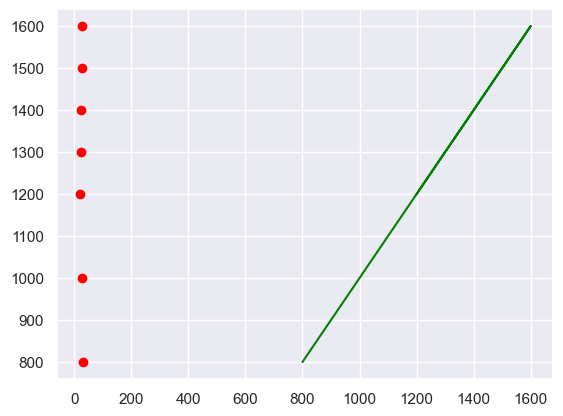

In [56]:
plt.scatter(df1['age'],df1['salary'],color='red',label='actual data')
plt.plot(df1['salary'],salary_pred,color='green',label='polynomial regression')
plt.show()

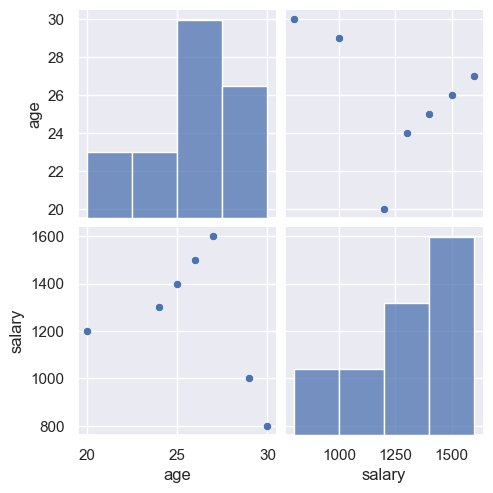

In [41]:

sns.set_theme(style='darkgrid')
sns.pairplot(df1)
plt.grid(True)
plt.show()

In [131]:
x=np.array([10,20,29,30,40,50,60,90,80,40]).reshape(-1,1) # sqfeets
y=np.array([100,120,130,150,190,89,90,900,39,980]).reshape(-1,1) #costs


In [132]:
poly=PolynomialFeatures(degree=4)
x_poly=poly.fit_transform(y).astype(int)

model=LinearRegression()
model.fit(x_poly,y)

y_pred=model.predict(x_poly)
print(y_pred)

print("=========================")
y_actual=y
errors=y_actual-y_pred
print(abs(errors).round(2))

[[ 99.99998149]
 [119.99998129]
 [129.99998103]
 [149.99998024]
 [189.99997766]
 [ 88.99998141]
 [ 89.99998142]
 [900.00004835]
 [ 38.99997912]
 [980.00010799]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [96]:
print(model.intercept_.round(2),model.coef_)

[199.85] [[ 0.        -2.537391   0.0090149]]


In [88]:
model.score(x,y)

ValueError: X has 1 features, but LinearRegression is expecting 3 features as input.

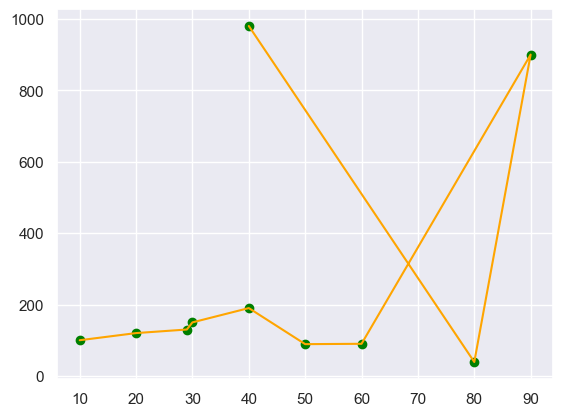

In [134]:
plt.scatter(x,y,color='green',label='actul data')
plt.plot(x,y_pred,color='orange',label='PolynomialFeatures')
plt.show()

https://www.youtube.com/watch?v=0V2PRq0w94Y
https://www.youtube.com/watch?v=XS_M_YeoW5U


